In [10]:
# Packages

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, coalesce, lit, expr, round, when, monotonically_increasing_id, pandas_udf
from pyspark.sql import DataFrame
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pickle
import sys
import os
import subprocess
import warnings
from math import isfinite

In [2]:
# Debug to run from time to time to check if there's a SparkSession running
from pyspark.sql import SparkSession

spark = SparkSession.getActiveSession()
if spark is not None:
    print("A Spark session is running.")
else:
    print("No active Spark session.")

No active Spark session.


In [3]:
# Start sparksession
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
        .appName("MSDS Assignment 1")                
        .master("local[6]")                   
        .config("spark.driver.memory", "6g")  
        .config("spark.executor.memory", "4g")
        .config("spark.sql.shuffle.partitions", "12")
        .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

26/04/06 12:34:21 WARN Utils: Your hostname, Jonathans-MacBook-Pro-16.local resolves to a loopback address: 127.0.0.1; using 192.168.100.190 instead (on interface en0)
26/04/06 12:34:21 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/06 12:34:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/06 12:34:22 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [4]:
spark

In [5]:
df = spark.read.csv("../data/synthetic_mobile_money_transaction_dataset.csv", header=True, inferSchema=True)
df.show(5)

+----+---------------+--------+----------------+---------------+---------------+----------------+---------------+---------------+-------+
|step|transactionType|  amount|       initiator|oldBalInitiator|newBalInitiator|       recipient|oldBalRecipient|newBalRecipient|isFraud|
+----+---------------+--------+----------------+---------------+---------------+----------------+---------------+---------------+-------+
|   0|       TRANSFER|19824.96|4537027967639631|      187712.18|      167887.22|4875702729424478|           8.31|       19833.27|      1|
|   0|        PAYMENT|  598.97|4296267625767470|           8.92|           8.92|      25-0000401|            0.0|            0.0|      0|
|   0|        PAYMENT|  545.85|4178224023847746|           93.6|        -452.25|      13-0001587|            0.0|         545.85|      0|
|   0|       TRANSFER|19847.01|4178224023847746|        -452.25|      -20299.26|4096920916696293|        4011.72|       23858.74|      1|
|   0|        PAYMENT|  546.89|477

In [6]:
# Data Exploration
df.printSchema()
df.describe().show()

root
 |-- step: integer (nullable = true)
 |-- transactionType: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- initiator: long (nullable = true)
 |-- oldBalInitiator: double (nullable = true)
 |-- newBalInitiator: double (nullable = true)
 |-- recipient: string (nullable = true)
 |-- oldBalRecipient: double (nullable = true)
 |-- newBalRecipient: double (nullable = true)
 |-- isFraud: integer (nullable = true)



26/04/06 12:34:36 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
[Stage 3:=================================================>         (5 + 1) / 6]

+-------+-----------------+---------------+-----------------+--------------------+------------------+------------------+--------------------+------------------+------------------+-------------------+
|summary|             step|transactionType|           amount|           initiator|   oldBalInitiator|   newBalInitiator|           recipient|   oldBalRecipient|   newBalRecipient|            isFraud|
+-------+-----------------+---------------+-----------------+--------------------+------------------+------------------+--------------------+------------------+------------------+-------------------+
|  count|          1720181|        1720181|          1720181|             1720181|           1720181|           1720181|             1720181|           1720181|           1720181|            1720181|
|   mean|65.55528633324052|           NULL|52538.67961220848|4.499951976758763...|2433757.5979887433| 2443879.729006279|4.501318368831969E15|108508.32875252634|122277.21539521578|0.10203461147402512|


In [7]:
df.count()

1720181

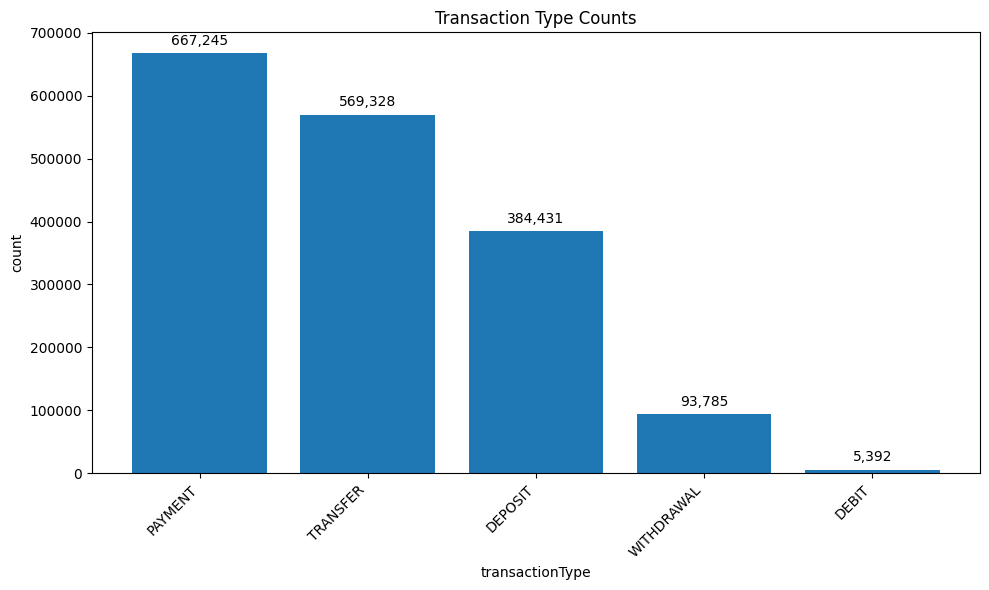

26/04/06 13:06:29 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 195372 ms exceeds timeout 120000 ms
26/04/06 13:06:29 WARN SparkContext: Killing executors is not supported by current scheduler.
26/04/06 13:06:31 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

In [11]:
total = df.count()

value_counts = (
    df.groupBy("transactionType")
      .count()
      .withColumn("pct", round(col("count") / total, 4))
      .orderBy(col("count").desc())
)

pdf = value_counts.toPandas()
pdf = pdf.sort_values("count", ascending=False)

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(pdf['transactionType'], pdf['count'], color='C0')

# Format labels (integers) and place them above bars
ax.bar_label(bars, labels=[f"{int(v):,}" for v in pdf['count']], padding=4)

ax.set_xlabel('transactionType')
ax.set_ylabel('count')
ax.set_title('Transaction Type Counts')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


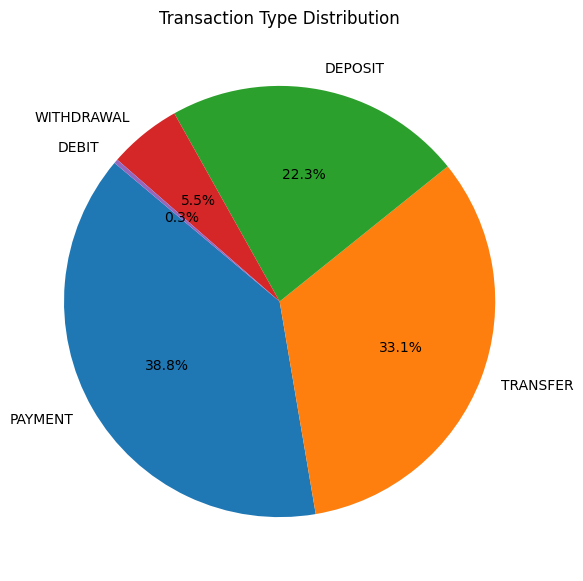

In [10]:
N = 8
top = pdf.head(N).copy()
others = pdf.iloc[N:]['count'].sum()
if others > 0:
    top = top.append({'transactionType':'Other', 'count':others, 'pct': others/total}, ignore_index=True)

# pie
plt.figure(figsize=(7,7))
plt.pie(top['count'], labels=top['transactionType'], autopct='%1.1f%%', startangle=140)
plt.title('Transaction Type Distribution')
plt.show()

In [11]:
counts_df = (
    df.groupBy("isFraud")
      .count()
      .orderBy(col("count").desc())
)

total = df.count()
counts_df = counts_df.withColumn("pct", col("count") / total)

pdf = counts_df.toPandas()

pdf = pdf.sort_values("count", ascending=False).reset_index(drop=True)
print(pdf)

   isFraud    count       pct
0        0  1544663  0.897965
1        1   175518  0.102035


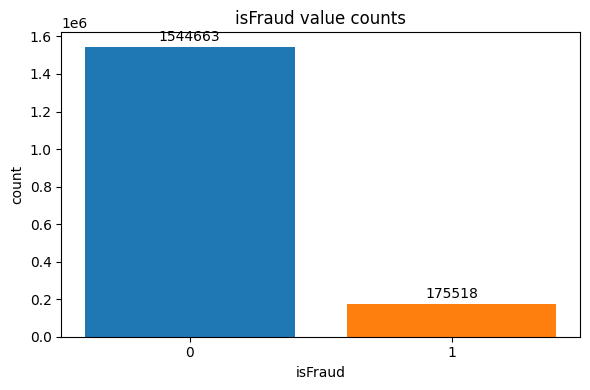

In [12]:
labels = pdf["isFraud"].astype(str)   # '0' and '1'
counts = pdf["count"]

plt.figure(figsize=(6,4))
plt.bar(labels, counts, color=["C0","C1"])
plt.xlabel("isFraud")
plt.ylabel("count")
plt.title("isFraud value counts")
for i, v in enumerate(counts):
    plt.text(i, v + max(counts)*0.01, f"{int(v)}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

In [9]:
# numerical_columns = ['amount', 'oldBalInitiator', 'newBalInitiator', 'oldBalRecipient', 'newBalRecipient']
# features_spark = df.select(*numerical_columns)

## Feature Engineering

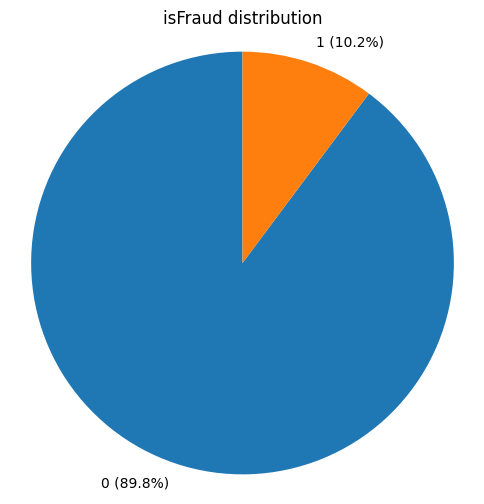

In [13]:
plt.figure(figsize=(6,6))
sizes = pdf["count"]
labels = pdf["isFraud"].astype(str) + " (" + (pdf["pct"]*100).round(2).astype(str) + "%)"
plt.pie(sizes, labels=labels, autopct=None, startangle=90, colors=["C0","C1"])
plt.title("isFraud distribution")
plt.axis("equal")
plt.show()

Since the ‘amount’ field seems to sometimes deviate from the difference between the Initiator and the new balances of one or both of the transaction parties, we decided to include these differences in the data as two additional features: ‘changebalanceInitiator’ and ‘changebalanceRecipient’.

In [ ]:
# features[‘changebalanceInitiator’] = features[‘newBalInitiator’] — features[‘oldBalInitiator’]
# features[‘changebalanceRecipient’] = features[‘newBalRecipient’] — features[‘oldBalRecipient’]

In [10]:
# features = df.select(
#     "amount",
#     "oldBalInitiator",
#     "newBalInitiator",
#     "oldBalRecipient",
#     "newBalRecipient"
# ).withColumn(
#     "changebalanceInitiator",
#     coalesce(col("newBalInitiator").cast("double"), lit(0.0)) - coalesce(col("oldBalInitiator").cast("double"), lit(0.0))
# ).withColumn(
#     "changebalanceRecipient",
#     coalesce(col("newBalRecipient").cast("double"), lit(0.0)) - coalesce(col("oldBalRecipient").cast("double"), lit(0.0))
# )

All numerical features can easily be used as inputs to the model, so the fields ‘amount’, ‘oldBalInitiator’, ‘newBalInitiator’, ‘oldBalRecipient’ and ‘newBalRecipient’ will be used as features as they are.

Since the ‘step’ field gives us the relative timestamps of all transactions in an hourly resolution, we can derive the (hourly) time of the day when the transaction occurred. To do this we simply transform the ‘step’ field by applying the modulo of 24.

In [8]:
# Feature Engineering
df = df.withColumn(
    "balance_change_initiator",
    F.col("newBalInitiator") - F.col("oldBalInitiator")
).withColumn(
    "balance_change_recipient",
    F.col("newBalRecipient") - F.col("oldBalRecipient")
).withColumn(
    # Ratio of amount to initiator's pre-tx balance (large = suspicious)
    "amount_to_balance_ratio",
    F.when(F.col("oldBalInitiator") > 0,
           F.col("amount") / F.col("oldBalInitiator"))
     .otherwise(F.lit(0.0))
).withColumn(
    # Flag: initiator balance drained to near-zero after tx
    "zero_out_flag",
    F.when(
        (F.col("newBalInitiator") < 1.0) & (F.col("oldBalInitiator") > 0),
        F.lit(1.0)
    ).otherwise(F.lit(0.0))
).withColumn(
    "log_amount",
    F.log1p(F.col("amount"))
).withColumn(
    "log_old_bal_initiator",
    F.log1p(F.col("oldBalInitiator"))
).withColumn(
    "log_new_bal_initiator",
    F.log1p(F.col("newBalInitiator"))
)
 
df.cache()


DataFrame[step: int, transactionType: string, amount: double, initiator: bigint, oldBalInitiator: double, newBalInitiator: double, recipient: string, oldBalRecipient: double, newBalRecipient: double, isFraud: int, balance_change_initiator: double, balance_change_recipient: double, amount_to_balance_ratio: double, zero_out_flag: double, log_amount: double, log_old_bal_initiator: double, log_new_bal_initiator: double]

In [ ]:
# Anomalous transaction detection
# Encode Transaction Type
tx_indexer = StringIndexer(
    inputCol="transactionType",
    outputCol="tx_type_idx",
    handleInvalid="keep"
)
tx_encoder = OneHotEncoder(
    inputCols=["tx_type_idx"],
    outputCols=["tx_type_ohe"]
)
 
# Per-customer rolling / contextual features
# Window over initiator ordered by step
w_init = Window.partitionBy("initiator").orderBy("step")
w_init_all = Window.partitionBy("initiator")
 
df = (
    df
    # lag features
    .withColumn("prev_amount",
                F.lag("amount", 1).over(w_init))
    .withColumn("amount_delta",
                F.col("amount") - F.col("prev_amount"))
    .withColumn("rolling_avg_amount_3",
                F.avg("amount").over(w_init.rowsBetween(-3, -1)))
    .withColumn("rolling_avg_amount_10",
                F.avg("amount").over(w_init.rowsBetween(-10, -1)))
    # deviation from personal average
    .withColumn("personal_avg_amount",
                F.avg("amount").over(w_init_all))
    .withColumn("amount_vs_personal_avg",
                F.col("amount") / F.col("personal_avg_amount"))
    # step gap from previous tx
    .withColumn("prev_step",
                F.lag("step", 1).over(w_init))
    .withColumn("step_gap",
                F.col("step") - F.col("prev_step"))
    .fillna(0.0)
)
 
# Assemble Anomaly Features
anomaly_feature_cols = [
    "log_amount",
    "log_old_bal_initiator",
    "log_new_bal_initiator",
    "amount_to_balance_ratio",
    "zero_out_flag",
    "balance_change_initiator",
    "balance_change_recipient",
    "amount_vs_personal_avg",
    "step_gap",
]
 
ano_assembler = VectorAssembler(
    inputCols=anomaly_feature_cols,
    outputCol="ano_raw_features",
    handleInvalid="skip"
)
ano_scaler = StandardScaler(
    inputCol="ano_raw_features",
    outputCol="ano_scaled_features",
    withStd=True, withMean=True
)
 
ano_prep_pipeline = Pipeline(stages=[ano_assembler, ano_scaler])
ano_prep_model    = ano_prep_pipeline.fit(df)
df_ano            = ano_prep_model.transform(df)
df_ano.cache()